In [15]:
import pandas as pd

df_evaluations_all=pd.read_json("./evaluations/evaluations_results_pipeline_QS1.json")
print("DF shape;", df_evaluations_all.shape)
print("Corpus évalués:", df_evaluations_all["corpus"].unique())

df_evaluations=df_evaluations_all[df_evaluations_all["corpus"]=='Un-cerveau-comment-ca-marche'].reset_index().copy()

used_judges=[el.split("_")[-1] for el in df_evaluations.columns if "custom_evaluation_text" in el]
print("used_judges:\n", used_judges)

models_ratio_scores=[]
for judge in used_judges:
    label_metric=f"{judge}_ratio_score"
    score=round(df_evaluations[f"score_B (RAG)_{judge}"]/df_evaluations[f"score_A (réf.)_{judge}"], 2)    
    if score.any():
        df_evaluations[label_metric]=score
        models_ratio_scores.append(label_metric)



display(df_evaluations.drop(columns=[
    "question", "date", 'dataset', "theme", 'information_source',
    "reponse_reference", "response", "category", 
    #"custom_evaluation_text_gpt-5.2", 
    # "custom_evaluation_text_gpt-5-mini", "custom_evaluation_text_gemini-3-flash-preview",
    # "custom_evaluation_text_gemini-3.1-pro-preview"
    # 'score_A (réf.)_gemini-3.1-pro-preview', 'score_B (RAG)_gemini-3.1-pro-preview', 
     'score_A (réf.)_gemini-3-flash-preview', 'score_B (RAG)_gemini-3-flash-preview', 
     'score_A (réf.)_gpt-5.2', 'score_B (RAG)_gpt-5.2', 
    'score_A (réf.)_gpt-5-mini', 'score_B (RAG)_gpt-5-mini',    
    

]))

print("\n===Ratio scores group by model et rag type:===\n")
for s in models_ratio_scores:    
    print(s)
    display(df_evaluations.groupby(["model", 'rag_type'])[s].mean().reset_index())



DF shape; (130, 31)
Corpus évalués: ['La-France-est-elle-reformable' 'L-IA-notre-deuxieme-conscience'
 'Un-cerveau-comment-ca-marche']
used_judges:
 ['gemini-3.1-pro-preview', 'gpt-5.2', 'gemini-3-flash-preview', 'gpt-5-mini', 'kimi-k2.5', 'deepseek-v3.2']


,index,corpus,difficulty,rag_type,model,score_A (réf.)_gemini-3.1-pro-preview,score_B (RAG)_gemini-3.1-pro-preview,custom_evaluation_text_gemini-3.1-pro-preview,custom_evaluation_text_gpt-5.2,custom_evaluation_text_gemini-3-flash-preview,...,score_A (réf.)_kimi-k2.5,score_B (RAG)_kimi-k2.5,custom_evaluation_text_kimi-k2.5,score_A (réf.)_deepseek-v3.2,score_B (RAG)_deepseek-v3.2,custom_evaluation_text_deepseek-v3.2,gemini-3.1-pro-preview_ratio_score,gpt-5.2_ratio_score,kimi-k2.5_ratio_score,deepseek-v3.2_ratio_score
0,90,Un-cerveau-comment-ca-marche,basique,hybrid,Qwen3-235B-A22B-Instruct-2507:together,8,10,"{'score_A': 8, 'score_B': 10, 'meilleure_repon...","{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,NaN,NaN,1.25,1.12,1.12,NaN
1,91,Un-cerveau-comment-ca-marche,intermédiaire,hybrid,Qwen3-235B-A22B-Instruct-2507:together,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...","{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,NaN,NaN,1.11,1.12,1.12,NaN
2,92,Un-cerveau-comment-ca-marche,intermédiaire,hybrid,Qwen3-235B-A22B-Instruct-2507:together,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...","{'score_A': 9, 'score_B': 9, 'meilleure_repons...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,NaN,NaN,1.00,1.00,1.12,NaN
3,93,Un-cerveau-comment-ca-marche,expert,hybrid,Qwen3-235B-A22B-Instruct-2507:together,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...","{'score_A': 9, 'score_B': 9, 'meilleure_repons...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,NaN,NaN,1.00,1.00,1.12,NaN
4,94,Un-cerveau-comment-ca-marche,intermédiaire,hybrid,Qwen3-235B-A22B-Instruct-2507:together,10,2,"{'score_A': 10, 'score_B': 2, 'meilleure_repon...","{'score_A': 8, 'score_B': 3, 'meilleure_repons...",NaN,...,8.0,4.0,"{'score_A': 8, 'score_B': 4, 'meilleure_repons...",NaN,NaN,NaN,0.20,0.38,0.50,NaN
5,95,Un-cerveau-comment-ca-marche,basique,hybrid,Qwen3-235B-A22B-Instruct-2507:together,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...","{'score_A': 9, 'score_B': 10, 'meilleure_repon...",NaN,...,7.0,9.0,"{'score_A': 7, 'score_B': 9, 'meilleure_repons...",8.0,10.0,"{'score_A': 8, 'score_B': 10, 'meilleure_repon...",1.11,1.11,1.29,1.25
6,96,Un-cerveau-comment-ca-marche,intermédiaire,hybrid,Qwen3-235B-A22B-Instruct-2507:together,9,9,"{'score_A': 9, 'score_B': 9, 'meilleure_repons...","{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",1.00,1.12,1.12,1.12
7,97,Un-cerveau-comment-ca-marche,expert,hybrid,Qwen3-235B-A22B-Instruct-2507:together,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...","{'score_A': 8, 'score_B': 7, 'meilleure_repons...",NaN,...,7.0,9.0,"{'score_A': 7, 'score_B': 9, 'meilleure_repons...",7.0,9.0,"{\n ""score_A"": 7,\n ""score_B"": 9,\n ""meille...",1.00,0.88,1.29,1.29
8,98,Un-cerveau-comment-ca-marche,intermédiaire,hybrid,Qwen3-235B-A22B-Instruct-2507:together,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...","{'score_A': 8, 'score_B': 9, 'meilleure_repons...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",10.0,10.0,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",1.11,1.12,1.12,1.00
9,99,Un-cerveau-comment-ca-marche,basique,hybrid,Qwen3-235B-A22B-Instruct-2507:together,8,10,"{'score_A': 8, 'score_B': 10, 'meilleure_repon...","{'score_A': 9, 'score_B': 10, 'meilleure_repon...",NaN,...,8.0,9.0,"{'score_A': 8, 'score_B': 9, 'meilleure_repons...",9.0,10.0,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",1.25,1.11,1.12,1.11



===Ratio scores group by model et rag type:===

gemini-3.1-pro-preview_ratio_score


,model,rag_type,gemini-3.1-pro-preview_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:together,hybrid,1.0425
1,Qwen3-235B-A22B-Instruct-2507:together,hybrid_hyde,1.0535


gpt-5.2_ratio_score


,model,rag_type,gpt-5.2_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:together,hybrid,1.008
1,Qwen3-235B-A22B-Instruct-2507:together,hybrid_hyde,1.058


kimi-k2.5_ratio_score


,model,rag_type,kimi-k2.5_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:together,hybrid,1.134
1,Qwen3-235B-A22B-Instruct-2507:together,hybrid_hyde,1.163


deepseek-v3.2_ratio_score


,model,rag_type,deepseek-v3.2_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:together,hybrid,1.0400
1,Qwen3-235B-A22B-Instruct-2507:together,hybrid_hyde,1.3295


In [22]:
# inspecter une question
from IPython.display import Markdown
i=4
question=df_evaluations.loc[i, "question"]
# qtype=df_evaluations.loc[i, "type"]
resp=df_evaluations.loc[i, "response"]
ref=df_evaluations.loc[i, "reponse_reference"][0]
verdict=df_evaluations.loc[i, 'custom_evaluation_text_gemini-3.1-pro-preview']

print("\n=====\nQuestion:", question)
# print("\n---\nType:", qtype)

print("\n=====\nRéponse:")
display(Markdown(resp))

print("\n----\nReference:")

display(Markdown(ref))

print(verdict)


=====
Question: Comment le cortex préfrontal contrôle-t-il spécifiquement la contraction des muscles de la main lors d'un serrage de main purement automatique et routinier ?

=====
Réponse:


<think>
**Question :**  
Comment le cortex préfrontal contrôle-t-il spécifiquement la contraction des muscles de la main lors d'un serrage de main purement automatique et routinier ?

---

**Raisonnement :**  
Le contexte fourni ne contient aucun fragment de document (retrieval absent), bien que le corpus distillé soit disponible. Le corpus distillé présente des informations générales sur le cortex préfrontal, notamment son rôle dans la planification, la régulation émotionnelle, l’anticipation d’actions et la délibération (C10, C28, C29, C34, C35). Il mentionne aussi l’activation de neurones préparatoires pendant un délai d’attente avant une action (C35), ce qui suggère un rôle dans la préparation motrice. Cependant, aucune information, ni dans le corpus distillé ni dans les fragments (absents), ne décrit le contrôle moteur spécifique des muscles de la main, ni le mécanisme par lequel le cortex préfrontal participe à un acte automatique comme un serrage de main.

En particulier, le contrôle fin des muscles est généralement attribué au cortex moteur primaire et aux voies pyraminales, avec une modulation possible du cortex préfrontal dans des contextes sociaux ou intentionnels. Mais ces détails anatomiques ou fonctionnels précis ne sont pas présents dans les données disponibles.

Étant donné l’absence totale de fragments et l’insuffisance du corpus distillé pour répondre à une question aussi spécifique et technique, il n’est pas possible de fournir une réponse étayée et précise.

---

**Réponse :**  
Contexte absent

---

**Sources :**  
Aucune – le retrieval est vide et le corpus distillé ne contient pas d’information suffisamment précise pour répondre à la question.


----
Reference:


Lors d'un serrage de main purement automatique et routinier, le cortex préfrontal n'intervient pas ou très peu. Le texte précise que ce sont de nombreuses autres structures, situées au sein de la partie motrice du cerveau, qui se chargent de contracter et décontracter les muscles. Le cortex préfrontal n'intervient que si la situation sort de l'ordinaire et nécessite une véritable prise de décision (par exemple, se demander s'il faut ou non serrer la main de la personne).

{'score_A': 10, 'score_B': 2, 'meilleure_reponse': 'A', 'evaluation': {'verdict': 'La réponse A corrige de manière pertinente la prémisse de la question en se basant sur le corpus, tandis que la réponse B échoue à répondre en indiquant une absence de contexte.', 'points_cles': {'communs': [], 'specifiques_A': ["Le cortex préfrontal n'intervient pas dans une action routinière", 'Les structures motrices se chargent de la contraction', "L'intervention a lieu uniquement lors d'une prise de décision"], 'specifiques_B': ["Mention d'une absence de contexte"]}, 'analyse_A': {'qualite': 'Répond parfaitement à la question en clarifiant le rôle exact (ou plutôt le non-rôle) du cortex préfrontal dans les actions automatiques.', 'limites': 'Aucune limite notable.'}, 'analyse_B': {'qualite': 'Raisonnement transparent sur son manque de contexte fourni.', 'limites': 'Ne fournit aucune réponse à la question posée, signalant une erreur de récupération (retrieval absent).'}, 'erreurs_critiques_A': [], 'e

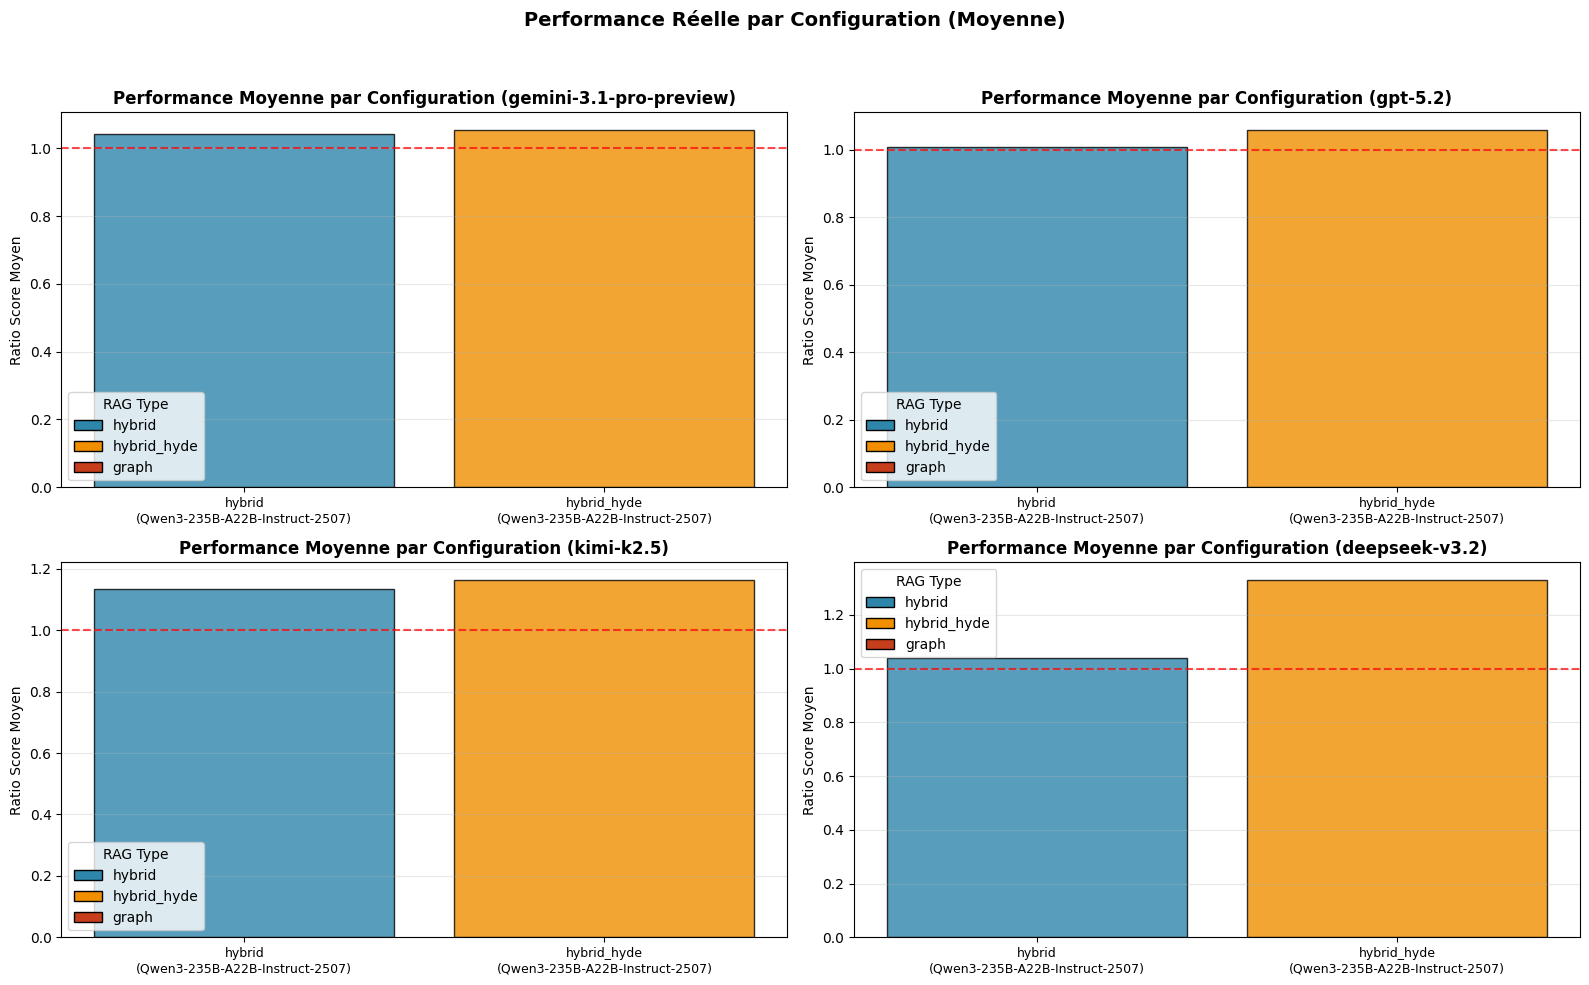

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_viz = df_evaluations.copy()
df_viz['model_short'] = df_viz['model'].str.split(':').str[0]

# Calcul des moyennes
models_ratio_means=[
    {
        "label": m.split("_r")[0],
        "stats": df_viz.groupby(['model_short', 'rag_type'])[m].mean().reset_index()
    }
    for m in models_ratio_scores
]

# Correction 1: figsize plus grand pour 4 graphiques
# Correction 2: flatten() pour accéder aux axes en 1D
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

models = df_viz['model_short'].unique()
colors = {'hybrid': '#2E86AB', 'hybrid_hyde': '#F18F01', 'graph': '#C73E1D'}

axes_stats_models=[]
for axe, stats_model in zip(axes, models_ratio_means):
    print
    axes_stats_models.append((axe, stats_model["stats"], stats_model["label"]))
    
for ax, data, title in axes_stats_models:    
    x_pos = 0
    width = 0.25
    positions = []
    labels = []
    
    for model in models:
        subset = data[data['model_short'] == model]
        for _, row in subset.iterrows():
            positions.append(x_pos)
            labels.append(f"{row['rag_type']}\n({row['model_short']})")
            ax.bar(x_pos, row.iloc[2], width, 
                   color=colors[row['rag_type']], 
                   edgecolor='black', alpha=0.8)
            x_pos += width + 0.05
        
        x_pos += 0.1
    
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Ratio Score Moyen', fontsize=10)
    ax.set_title(f'Performance Moyenne par Configuration ({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[r], edgecolor='black', label=r) 
                       for r in ['hybrid', 'hybrid_hyde', 'graph']]
    ax.legend(handles=legend_elements, title='RAG Type')

plt.suptitle('Performance Réelle par Configuration (Moyenne)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

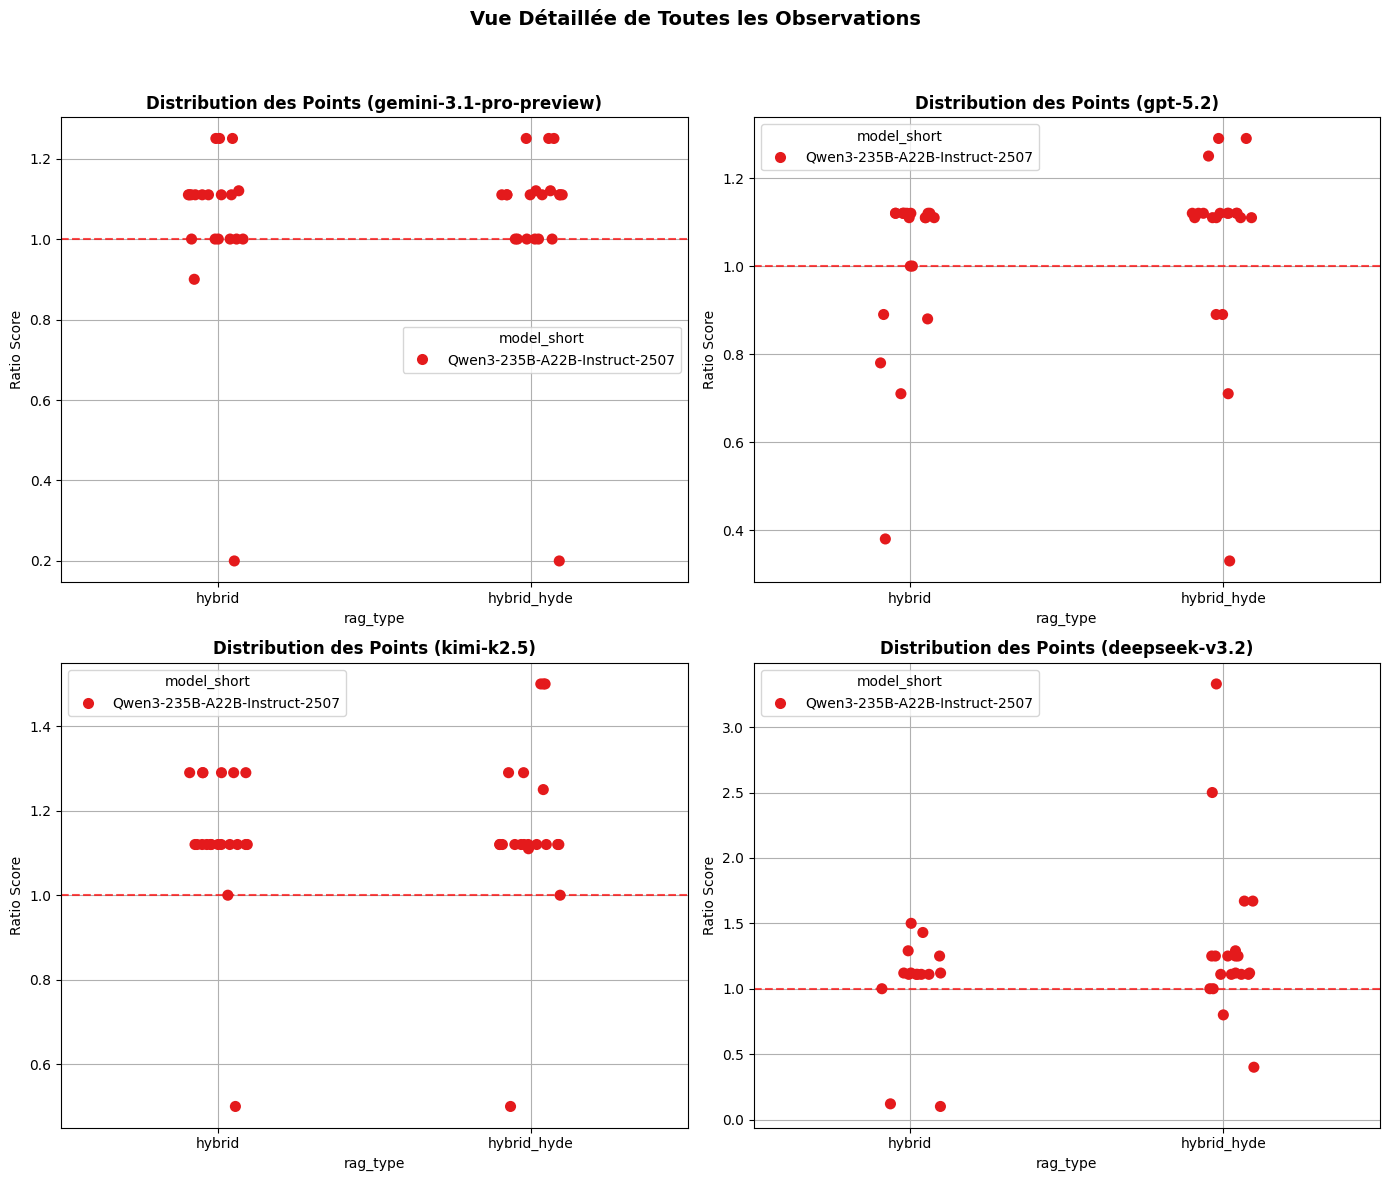

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Correction : convertir en tableau 1D


for axe, model in zip(axes, models_ratio_scores):
    sns.stripplot(data=df_viz, x='rag_type', y=model, 
                hue='model_short', ax=axe, size=8, palette='Set1')
    axe.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    axe.set_title(f'Distribution des Points ({model.split("_r")[0]})', fontweight='bold')
    axe.set_ylabel('Ratio Score')
    axe.grid()

plt.suptitle('Vue Détaillée de Toutes les Observations', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()